<p align="center">
• <a href="https://mayzune.com/"><strong>May Zune</strong></a> •
<a href="https://github.com/hellomayzune"><strong>GitHub</strong></a> •
<a href="https://orcid.org/0000-0003-0282-2633"><strong>ORCID</strong></a> •
<a href="https://scholar.google.com/citations?user=LmP8B_4AAAAJ&hl=en"><strong>Google Scholar</strong></a> •
<a href="https://www.researchgate.net/profile/May-Zune"><strong>ResearchGate</strong></a> •
<a href="https://www.linkedin.com/in/mayzune//"><strong>Linkedin</strong></a> •
</p>

# Scalable Clustering for Large Housing Datasets

This notebook provides a practical, real-world demonstration of why **plain Hierarchical Agglomerative Clustering (HAC)** does not scale effectively to this housing dataset, and how **Mini-Batch K-Means** and a **BIRCH + HAC hybrid** provide more scalable alternatives.

Throughout the notebook, I combine **exploratory data analysis (EDA)**, data preparation, clustering, and **cluster profiling** to understand both the computational trade-offs and the characteristics of the resulting clusters.

## Notebook Structure

1. **Setup & EDA**
2. **Limitations of Hierarchical Clustering**
3. **Data Checks & Preprocessing**
4. **Mini-Batch K-Means Clustering**
5. **Hybrid BIRCH + Hierarchical Clustering Model**

## Practical Applicability and Comparison with a Rule-Based Approach

Although the notebook demonstrates that clustering can be successfully applied to the housing dataset using machine learning techniques, its practical applicability to a real-world project remains limited. In particular, the analysis focuses primarily on demonstrating the feasibility and scalability of clustering methods rather than developing a clearly interpretable and actionable housing classification framework.

This limitation becomes more apparent when compared with the **[A Rule-Based Method for Classifying Housing Archetypes](https://github.com/hellomayzune/A-Rule-Based-Method-for-Classifying-Housing-Archetypes-)** study, which takes a more application-oriented approach by using predefined rules to classify properties into meaningful housing archetypes. Such an approach provides greater interpretability and makes the resulting classifications easier to understand, validate, and apply within a real-world housing context.

Therefore, while the clustering approaches explored in this notebook demonstrate the technical potential of unsupervised machine learning for identifying patterns within housing data, further work would be required to translate these clusters into robust, interpretable, and practically useful housing archetypes. A comparison with the rule-based approach highlights the trade-off between **data-driven cluster discovery** and **domain-informed, interpretable classification**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import Birch, AgglomerativeClustering, MiniBatchKMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
# Load data
df = pd.read_csv('./SourceFileClean/CSV_UKBe16_Resi_SouthYorkshire-clean.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614460 entries, 0 to 614459
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   premise_age          614460 non-null  object 
 1   premise_type         614460 non-null  object 
 2   premise_floor_count  614402 non-null  float64
 3   bungalow             449574 non-null  object 
 4   height               614292 non-null  float64
 5   building_area        614460 non-null  float64
 6   gross_area           614402 non-null  float64
dtypes: float64(4), object(3)
memory usage: 32.8+ MB


In [4]:
df.head(3)

,premise_age,premise_type,premise_floor_count,bungalow,height,building_area,gross_area
0,Post 1999,Semi-detached,2.0,Not a bungalow,10.2,245.2,490.4
1,1960-1979,Detached,1.0,Bungalow (high confidence),6.3,194.7,194.7
2,1990-1999,Detached,1.0,Bungalow (moderate confidence),7.1,128.1,128.1


# EDA Visualizations

In [5]:
# Set style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig_sns_config = {'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14}
plt.rcParams.update(fig_sns_config)

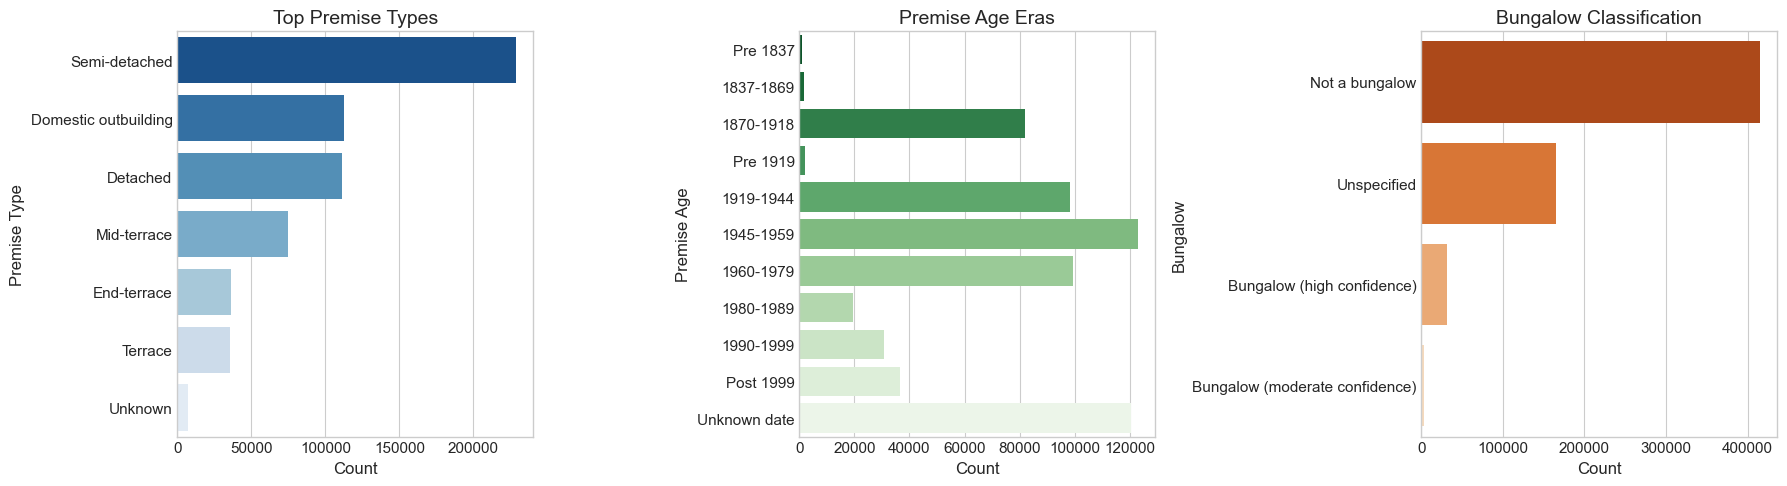

In [6]:
df_viz = df.copy()
df_viz['bungalow'] = df_viz['bungalow'].fillna('Unspecified')

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Figure 1: Categorical Distributions (Updated to fix Seaborn warning)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Top Premise Types
type_counts = df_viz['premise_type'].value_counts().head(7).reset_index()
type_counts.columns = ['premise_type', 'count']
sns.barplot(
    data=type_counts, 
    x='count', 
    y='premise_type', 
    hue='premise_type', 
    palette='Blues_r', 
    legend=False, 
    ax=axes[0]
)
axes[0].set_title('Top Premise Types')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Premise Type')

# Premise Age Eras
age_order = ['Pre 1837', '1837-1869', '1870-1918', 'Pre 1919', '1919-1944', '1945-1959', '1960-1979', '1980-1989', '1990-1999', 'Post 1999', 'Unknown date']
age_counts = df_viz['premise_age'].value_counts().reindex([a for a in age_order if a in df_viz['premise_age'].values]).reset_index()
age_counts.columns = ['premise_age', 'count']
sns.barplot(
    data=age_counts, 
    x='count', 
    y='premise_age', 
    hue='premise_age', 
    palette='Greens_r', 
    legend=False, 
    ax=axes[1]
)
axes[1].set_title('Premise Age Eras')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Premise Age')

# Bungalow Classification
bung_counts = df_viz['bungalow'].value_counts().reset_index()
bung_counts.columns = ['bungalow', 'count']
sns.barplot(
    data=bung_counts, 
    x='count', 
    y='bungalow', 
    hue='bungalow', 
    palette='Oranges_r', 
    legend=False, 
    ax=axes[2]
)
axes[2].set_title('Bungalow Classification')
axes[2].set_xlabel('Count')
axes[2].set_ylabel('Bungalow')

plt.tight_layout()
#plt.savefig('eda_categorical_distributions_fixed.png', dpi=300)
#plt.close()

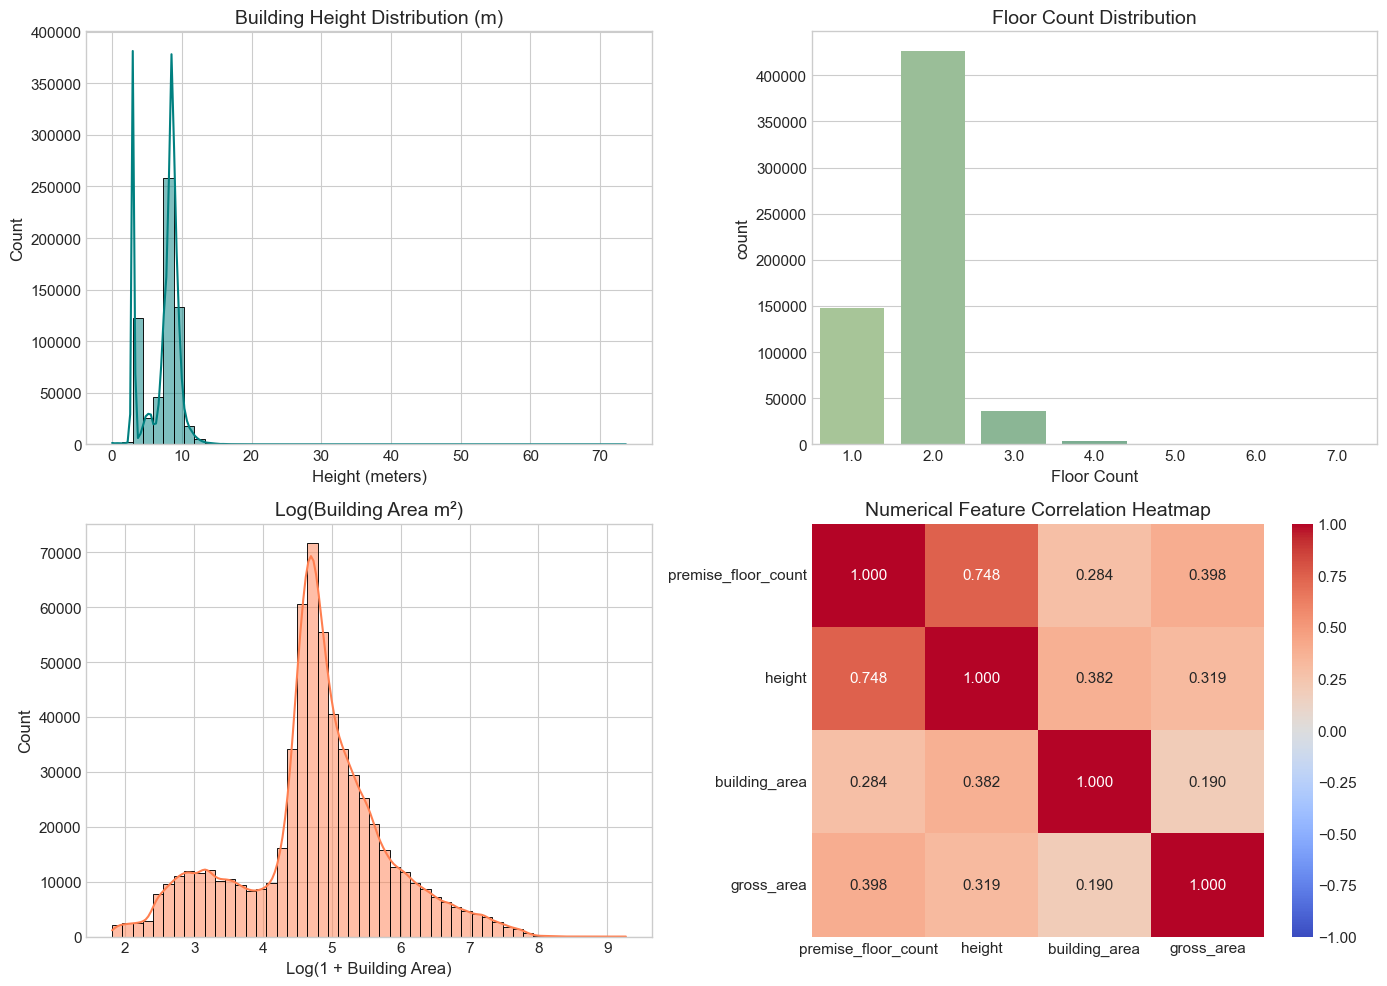

In [7]:
# Figure 2: Floor Count Distribution (countplot fix)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df_viz['height'].dropna(), bins=50, kde=True, ax=axes[0,0], color='teal')
axes[0,0].set_title('Building Height Distribution (m)')
axes[0,0].set_xlabel('Height (meters)')

sns.countplot(
    data=df_viz, 
    x='premise_floor_count', 
    hue='premise_floor_count', 
    palette='crest', 
    legend=False, 
    ax=axes[0,1]
)
axes[0,1].set_title('Floor Count Distribution')
axes[0,1].set_xlabel('Floor Count')
axes[0,1].set_xlim(-0.5, 6.5)

sns.histplot(np.log1p(df_viz['building_area']), bins=50, kde=True, ax=axes[1,0], color='coral')
axes[1,0].set_title('Log(Building Area m²)')
axes[1,0].set_xlabel('Log(1 + Building Area)')

corr = df_viz[['premise_floor_count', 'height', 'building_area', 'gross_area']].corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', ax=axes[1,1], vmin=-1, vmax=1)
axes[1,1].set_title('Numerical Feature Correlation Heatmap')

plt.tight_layout()
#plt.savefig('eda_numerical_distributions_fixed.png', dpi=300)
#plt.close()

#print("Executed without Seaborn deprecation warnings.")

# Limitations of hierarchical clustering - Housing Stock Clustering Analysis

This housing stock dataset contains **614,460 residential property records** across seven features:

- `premise_age`
- `premise_type`
- `premise_floor_count`
- `bungalow`
- `height`
- `building_area`
- `gross_area`

### 1. Early Merges and Suboptimal Results

Hierarchical Agglomerative Clustering (HAC) builds clusters bottom-up by greedily merging the two closest clusters at each step. Because HAC cannot unmerge or reassign points once a decision is made, early sub-optimal decisions can permanently affect higher-level cluster structures in this dataset.

### 2. Limitations of Hierarchical Agglomerative Clustering

HAC is unsuitable for this dataset due to its high computational requirements. With **614,460 records**, calculating pairwise distances would require over **700 GB of memory**, making direct HAC impractical.

The method is also sensitive to extreme outliers, such as unusually large buildings or heights, which can distort cluster formation. Additionally, the dataset contains both numerical and categorical features. One-hot encoding categorical variables increases dimensionality, causing distances to become less meaningful due to the **curse of dimensionality**.

Therefore, sampling or alternative clustering methods are recommended.

### 3. HAC vs. K-Means

HAC and K-Means differ significantly in their approach and efficiency. HAC makes irreversible cluster merges, is computationally expensive, and is highly sensitive to outliers. However, it can identify non-spherical cluster shapes and does not require the number of clusters to be specified in advance.

In contrast, **K-Means** iteratively reallocates data points, making it more flexible and efficient for large datasets. It requires the number of clusters (`K`) to be chosen beforehand and generally works best with spherical, well-separated clusters.

### 4. Mitigation Strategies

Several strategies can improve clustering performance:

- **BIRCH or Mini-Batch K-Means** can reduce the 614,460 records into smaller representative clusters before applying hierarchical clustering.
- **Robust scaling** using the median and interquartile range can reduce the influence of extreme values.
- Severe outliers can be **filtered or treated separately**.
- For mixed numerical and categorical data, **Gower’s Distance** provides a suitable similarity measure.
- Dimensionality reduction methods such as **UMAP** can simplify the data.
- Alternatively, **HDBSCAN** can identify dense clusters while treating outliers as noise rather than forcing them into clusters

# Check data

In [8]:
# Check missing values count
print("Missing values:")
print(df.isnull().sum())

print("\nValue counts for categorical columns:")
for col in ['premise_age', 'premise_type', 'bungalow']:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))

Missing values:
premise_age                 0
premise_type                0
premise_floor_count        58
bungalow               164886
height                    168
building_area               0
gross_area                 58
dtype: int64

Value counts for categorical columns:

--- premise_age ---
premise_age
1945-1959       123060
Unknown date    120490
1960-1979        99239
1919-1944        98261
1870-1918        82136
Post 1999        36538
1990-1999        30878
1980-1989        19550
Pre 1919          1875
1837-1869         1564
Pre 1837           869
Name: count, dtype: int64

--- premise_type ---
premise_type
Semi-detached           228871
Domestic outbuilding    112792
Detached                110878
Mid-terrace              74453
End-terrace              35886
Terrace                  35422
Unknown                   7167
Flat                      7146
Maisonette                1627
Enclosed end-terrace       161
Enclosed mid-terrace        57
Name: count, dtype: int64

--- bun

# Preprocessing

In [9]:
# 1. Preprocessing setup
# Fill NaN in bungalow with 'Unknown'
df_proc = df.copy()
df_proc['bungalow'] = df_proc['bungalow'].fillna('Unknown/Unspecified')

num_cols = ['premise_floor_count', 'height', 'building_area', 'gross_area']
cat_cols = ['premise_age', 'premise_type', 'bungalow']

# Preprocessing pipeline
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

X_prep = preprocessor.fit_transform(df_proc)
print("Preprocessed shape:", X_prep.shape)

# Find feature names
onehot_cols = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(cat_cols)
feature_names = num_cols + list(onehot_cols)

Preprocessed shape: (614460, 30)


In [10]:
import os

# Limit OpenMP threads prior to running calculations (optional safeguard)
os.environ["OMP_NUM_THREADS"] = "8"

import numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import calinski_harabasz_score, silhouette_score

# Sample for quick silhouette calculation
np.random.seed(42)
sample_idx = np.random.choice(X_prep.shape[0], size=20000, replace=False)
X_sample = X_prep[sample_idx]

k_range = range(2, 9)
inertias = []
silhouette_scores = []
ch_scores = []

for k in k_range:
    # Set batch_size >= 4096 to eliminate the MKL memory leak warning on Windows
    mbk = MiniBatchKMeans(
        n_clusters=k, batch_size=4096, random_state=42, n_init=3
    )
    mbk.fit(X_prep)
    inertias.append(mbk.inertia_)

    # Calculate metrics on sample for speed
    labels_sample = mbk.predict(X_sample)
    sil = silhouette_score(X_sample, labels_sample)
    ch = calinski_harabasz_score(X_sample, labels_sample)
    silhouette_scores.append(sil)
    ch_scores.append(ch)

    print(
        f"k={k}: Inertia={mbk.inertia_:.2f}, Silhouette={sil:.4f}, Calinski-Harabasz={ch:.2f}"
    )

k=2: Inertia=2524356.44, Silhouette=0.4409, Calinski-Harabasz=10328.96
k=3: Inertia=2101929.25, Silhouette=0.4610, Calinski-Harabasz=8851.34
k=4: Inertia=1940238.59, Silhouette=0.3660, Calinski-Harabasz=7109.12
k=5: Inertia=1803079.12, Silhouette=0.3432, Calinski-Harabasz=6244.04
k=6: Inertia=1657164.70, Silhouette=0.3683, Calinski-Harabasz=5871.14
k=7: Inertia=1580168.50, Silhouette=0.3755, Calinski-Harabasz=5389.72
k=8: Inertia=1519354.22, Silhouette=0.3424, Calinski-Harabasz=4946.45


In [11]:
# Let's inspect cluster profiles for k=3 and k=4

import os

# Set thread ceiling prior to execution
os.environ["OMP_NUM_THREADS"] = "8"

from sklearn.cluster import MiniBatchKMeans

# Inspect cluster profiles for k=3, 4, and 5
for k in [3, 4, 5]:
    # Increased batch_size to 4096 to prevent MKL memory leak warning on Windows
    mbk = MiniBatchKMeans(
        n_clusters=k, batch_size=4096, random_state=42, n_init=10
    )
    df_proc[f"cluster_{k}"] = mbk.fit_predict(X_prep)
    print(f"\n--- Cluster counts for k={k} ---")
    print(df_proc[f"cluster_{k}"].value_counts(normalize=True) * 100)

print("\nSummary for k=3:")
print(df_proc.groupby("cluster_3")[num_cols].mean())

print("\nTop premise_type per cluster_3:")
print(
    df_proc.groupby("cluster_3")["premise_type"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    .round(3)
)


--- Cluster counts for k=3 ---
cluster_3
0    70.694105
1    22.426033
2     6.879862
Name: proportion, dtype: float64

--- Cluster counts for k=4 ---
cluster_4
2    57.776096
1    21.892068
0    15.370244
3     4.961592
Name: proportion, dtype: float64

--- Cluster counts for k=5 ---
cluster_5
4    28.065619
3    23.961527
0    21.837711
1    19.837581
2     6.297562
Name: proportion, dtype: float64

Summary for k=3:
           premise_floor_count    height  building_area  gross_area
cluster_3                                                          
0                     2.047711  8.380497     169.948882  150.332077
1                     1.052662  3.285380      45.656729   34.694433
2                     2.198950  9.668666    1068.377710  224.029405

Top premise_type per cluster_3:
premise_type  Detached  Domestic outbuilding  Enclosed end-terrace  \
cluster_3                                                            
0                0.226                 0.000                   0

In [12]:
print("Summary for k=4:")
print(df_proc.groupby('cluster_4')[num_cols].mean())
print("\nTop premise_type per cluster_4:")
print(df_proc.groupby('cluster_4')['premise_type'].value_counts(normalize=True).unstack().fillna(0).round(3))
print("\nTop premise_age per cluster_4:")
print(df_proc.groupby('cluster_4')['premise_age'].value_counts(normalize=True).unstack().fillna(0).round(3))

Summary for k=4:
           premise_floor_count    height  building_area  gross_area
cluster_4                                                          
0                     2.452678  9.445172     329.701155  230.717126
1                     1.046875  3.225460      43.560413   33.039538
2                     1.947763  8.131915     142.541022  137.913946
3                     2.085222  9.478355    1235.872651  142.966308

Top premise_type per cluster_4:
premise_type  Detached  Domestic outbuilding  Enclosed end-terrace  \
cluster_4                                                            
0                0.114                 0.000                 0.001   
1                0.070                 0.838                 0.000   
2                0.253                 0.000                 0.000   
3                0.023                 0.000                 0.000   

premise_type  Enclosed mid-terrace  End-terrace   Flat  Maisonette  \
cluster_4                                          

# Mini-Batch K-Means processes data

Mini-Batch K-Means processes data in small random batches, significantly reducing computation time while producing results comparable to standard K-Means.

### Key Pipeline Components

1. **Feature Scaling (`StandardScaler`)**: Mini-Batch K-Means relies on Euclidean distance. Features like property price, floor space, or geographic coordinates operate on vastly different scales and must be standardized to a mean of 0 and variance of 1.

2. **Batch Processing (`batch_size=1024`)**: Random samples of size 1,024 are loaded into memory per iteration. This minimizes memory usage and yields faster convergence compared to standard K-Means.

3. **Hyperparameter Selection ($k$)**: The plot displays both **Inertia** (measuring cluster tightness) and **Silhouette Score** (measuring cluster separation). Look for the "elbow" point where inertia flattening coincides with a high silhouette score.

4. **Cluster Profiling**: Transposing `cluster_profiles.T` summarizes average attributes per cluster (e.g., high-value detached homes vs. urban apartments), providing actionable segmentation insights.

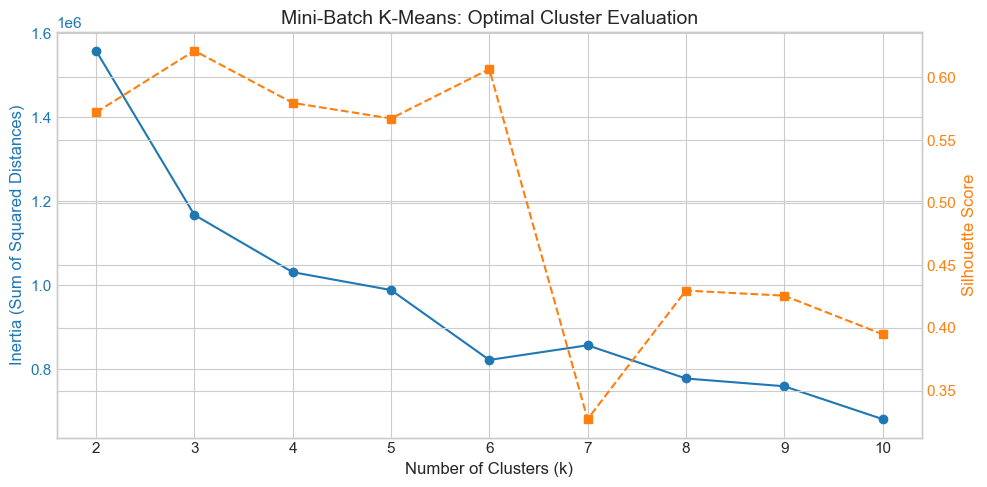


--- Cluster Mean Profiles ---
Cluster                       0           1          2            3
premise_floor_count    2.093097    1.342221   1.016354     2.204408
height                 8.511454    6.006596   2.992188     9.682545
building_area        180.333490  155.157539  27.643877  1195.969483
gross_area           152.303822  114.676726  22.888891   241.013003


In [13]:
import os

# Limit OpenMP threads before importing scikit-learn to prevent MKL memory leak on Windows
os.environ["OMP_NUM_THREADS"] = "4"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# 1. Load Dataset (assumed df is loaded)

# 2. Preprocessing & Feature Selection
# Drop identifiers/text columns; retain continuous numerical features (e.g., price, area, coordinates, beds, baths)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Handle missing values by imputing with median
X = df[numeric_cols].fillna(df[numeric_cols].median())

# Scale features (essential for distance-based clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Determine Optimal Clusters (Elbow Method & Silhouette Score)
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    # Updated batch_size to 4096 to prevent MKL memory leak
    mbk = MiniBatchKMeans(
        n_clusters=k, batch_size=4096, random_state=42, n_init=3
    )
    labels = mbk.fit_predict(X_scaled)
    inertias.append(mbk.inertia_)

    # Calculate silhouette score on a sample if dataset is large
    sample_size = min(5000, X_scaled.shape[0])
    score = silhouette_score(
        X_scaled, labels, sample_size=sample_size, random_state=42
    )
    silhouette_scores.append(score)

# Plot Elbow and Silhouette curves
fig, ax1 = plt.subplots(figsize=(10, 5))

color = "tab:blue"
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia (Sum of Squared Distances)", color=color)
ax1.plot(k_range, inertias, marker="o", color=color)
ax1.tick_params(axis="y", labelcolor=color)

ax2 = ax1.twinx()
color = "tab:orange"
ax2.set_ylabel("Silhouette Score", color=color)
ax2.plot(k_range, silhouette_scores, marker="s", linestyle="--", color=color)
ax2.tick_params(axis="y", labelcolor=color)

plt.title("Mini-Batch K-Means: Optimal Cluster Evaluation")
plt.grid(True)
plt.tight_layout()
plt.savefig("cluster_evaluation.png")
plt.show()

# 4. Fit Final Mini-Batch K-Means Model
optimal_k = 4
final_mbk = MiniBatchKMeans(
    n_clusters=optimal_k, batch_size=4096, random_state=42, n_init=10
)
df["Cluster"] = final_mbk.fit_predict(X_scaled)

# 5. Profile Clusters (Un-scale Centroids for Business Interpretation)
cluster_profiles = df.groupby("Cluster")[numeric_cols].mean()
print("\n--- Cluster Mean Profiles ---")
print(cluster_profiles.T)

# Save clustered dataset
df.to_csv("CSV_UKBe16_Resi_SouthYorkshire_Mini-Batch-K-Means-clustered.csv", index=False)

# Hybrid BIRCH-Hierarchical model

BIRCH handles scale efficiently by compressing large datasets into dense sub-clusters (Clustering Feature Tree), and Hierarchical Agglomerative Clustering then groups these sub-clusters into final global clusters.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import Birch, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

# 1. Load Dataset
file_path = "./SourceFileClean/CSV_UKBe16_Resi_SouthYorkshire-clean.csv"
df = pd.read_csv(file_path)

# 2. Select Numerical Features
# Automatically select numerical columns; adjust selection as needed
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Drop ID/non-predictive index columns if present
cols_to_exclude = ['id', 'ID', 'postcode', 'Postcode']
features = [col for col in numeric_cols if col not in cols_to_exclude]

X = df[features]

# 3. Preprocessing (Imputation & Standardization)
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# 4. Phase 1: BIRCH Micro-Clustering (Feature Tree Construction)
# threshold controls sub-cluster radius; branching_factor limits max children per node
birch_stage1 = Birch(threshold=0.5, branching_factor=50, n_clusters=None)
birch_stage1.fit(X_scaled)

# Extract sub-cluster centroids
subcluster_centroids = birch_stage1.subcluster_centers_
print(f"Number of sub-clusters created by BIRCH: {len(subcluster_centroids)}")

# 5. Phase 2: Hierarchical Agglomerative Clustering on Sub-clusters
n_final_clusters = 5  # Adjust target number of clusters

hac = AgglomerativeClustering(n_clusters=n_final_clusters, linkage='ward')
subcluster_labels = hac.fit_predict(subcluster_centroids)

# Map sub-cluster labels back to full dataset
full_dataset_subcluster_indices = birch_stage1.predict(X_scaled)
final_labels = subcluster_labels[full_dataset_subcluster_indices]

# Save labels to original DataFrame
df['BIRCH_HAC_Cluster'] = final_labels

# 6. Evaluation Metrics
sil_score = silhouette_score(X_scaled, final_labels)
db_score = davies_bouldin_score(X_scaled, final_labels)

print(f"\n--- Model Evaluation ---")
print(f"Silhouette Score: {sil_score:.4f}")
print(f"Davies-Bouldin Index: {db_score:.4f}")

# 7. Visualization: Dendrogram of BIRCH Sub-clusters
plt.figure(figsize=(10, 5))
Z = linkage(subcluster_centroids, method='ward')
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10.)
plt.title("Hierarchical Clustering Dendrogram (BIRCH Sub-clusters)")
plt.xlabel("Sub-cluster Sample Index / Cluster Size")
plt.ylabel("Distance (Ward)")
plt.tight_layout()
plt.show()

# 8. Visualization: 2D PCA Cluster Projection
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=final_labels, 
    palette='viridis', 
    alpha=0.6, 
    s=25
)
plt.title("Hybrid BIRCH-Hierarchical Clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

Number of sub-clusters created by BIRCH: 1169
